# **Time-Series Forecasting of Agricultural Production**

1. Import Required Libraries:

Explanation:

We import libraries for data handling, plotting, statistical tests, time-series models, machine learning metrics, and deep learning.

In [26]:
import pandas as pd # this data frame used for reading, filtering, and reshaping tabular data
import numpy as np # numerical operations
import matplotlib.pyplot as plt # used for plotting the time series
import matplotlib.ticker as ticker
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error

2. Load the FAOSTAT Dataset

Explanation:

We load the original FAOSTAT CSV file into a pandas DataFrame.

In [27]:
file_path = "Production_Crops_Livestock_E_All_Data.csv" # stores the location of your CSV file
df = pd.read_csv(file_path) # reads the CSV into a pandas DataFrame called df
df.head(10) # displays the first 5 rows so inspect the structure

C:\Users\soma mani deepak\AppData\Local\Temp\ipykernel_25380\3121368093.py:2: DtypeWarning: Columns (11,14,17,20,23,26,29,32,35,38,41,44,47,50,53,56,59,62,65,68,71,74,77,80,83,86,89,92,95,98,101,104,107,110,113,116,119,122,125,128,131,134,137,140,143,146,149,152,155,158,161,164,167,170,173,176,179,182,185,188,191,194,197,200) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path) # reads the CSV into a pandas DataFrame called df


,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N
0,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5312,Area harvested,ha,0.0,...,NaN,36462.00,A,NaN,37000.00,A,NaN,39794.00,I,NaN
1,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5412,Yield,kg/ha,NaN,...,NaN,1742.00,A,NaN,1810.80,A,NaN,1741.90,E,NaN
2,2,'004,Afghanistan,221,'01371,"Almonds, in shell",5510,Production,t,0.0,...,NaN,63515.00,A,NaN,67000.00,A,NaN,69315.64,I,NaN
3,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5312,Area harvested,ha,NaN,...,NaN,25403.00,E,NaN,25439.00,E,NaN,25400.00,E,NaN
4,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5412,Yield,kg/ha,NaN,...,NaN,704.00,E,NaN,704.00,E,NaN,704.30,E,NaN
5,2,'004,Afghanistan,711,'01654,"Anise, badian, coriander, cumin, caraway, fenn...",5510,Production,t,NaN,...,NaN,17883.38,E,NaN,17908.59,E,NaN,17889.49,E,NaN
6,2,'004,Afghanistan,515,'01341,Apples,5312,Area harvested,ha,2220.0,...,NaN,30163.00,A,NaN,31000.00,A,NaN,32280.00,I,NaN
7,2,'004,Afghanistan,515,'01341,Apples,5412,Yield,kg/ha,6801.8,...,NaN,10556.00,A,NaN,10451.60,A,NaN,10341.80,E,NaN
8,2,'004,Afghanistan,515,'01341,Apples,5510,Production,t,15100.0,...,NaN,318402.00,A,NaN,324000.00,A,NaN,333837.85,I,NaN
9,2,'004,Afghanistan,526,'01343,Apricots,5312,Area harvested,ha,4820.0,...,NaN,26731.00,A,NaN,25374.00,A,NaN,23132.00,I,NaN


3. Filter Dataset (Country, Crop, Production)

Explanation:

We select:

	•	One country
	•	One crop
	•	Production values only
  
This creates a clean univariate time series.

In [28]:
#countries = ["India","United Kindom","United States of America"]
country = "India"
crop = "Wheat"
df_filtered = df[
    (df["Area"] == country) &
    #(df["Area"].isin(countries))&
    (df["Item"] == crop) &
    (df["Element"] == "Production")]
df_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),...,Y2023F,Y2023N,Y2024,Y2024F,Y2024N
25786,100,'356,India,15,'0111,...,A,NaN,113292368.0,A,NaN


4. Data Cleaning

Explanation:

Remove missing values and ensure production values are positive.

In [29]:
year_columns = [col for col in df_filtered.columns if col.startswith("Y")]

ts = df_filtered[year_columns].T
ts.index = [int(''.join(filter(str.isdigit, year))) for year in year_columns]
ts.columns = ["Production"]
#df_filtered.dropna(inplace=True)
#df_filtered = df_filtered[df_filtered["Value"] > 0]
#df_filtered=df_filtered_raw.copy
#df_filtered.dropna(inplace=True) # Removes rows with missing production values
#df_filtered = df_filtered[df_filtered["Value"] > 0] # Removes zero or negative production values,Prevents distortions in plots and analysis
df_filtered.head()

,Area Code,Area Code (M49),Area,Item Code,Item Code (CPC),Item,Element Code,Element,Unit,Y1961,...,Y2021N,Y2022,Y2022F,Y2022N,Y2023,Y2023F,Y2023N,Y2024,Y2024F,Y2024N
25786,100,'356,India,15,'0111,Wheat,5510,Production,t,10997000.0,...,NaN,107742070.0,A,NaN,1.105537e+08,A,NaN,113292368.0,A,NaN


5. Convert to Time Series Format

Explanation:

We convert Year into a datetime index, which is required for time-series models.

In [32]:
# The 'Year' column has already been converted to a datetime index in the previous step.
# Therefore, the following two lines are redundant and cause a KeyError.
ts["Production"] = pd.to_numeric(ts["Production"],errors="coerce")

# Remove missing values
ts = ts.dropna()

# Remove zero or negative values
ts = ts[ts["Production"] > 0]

# Convert to datetime
ts.index = pd.to_datetime(ts.index, format="%Y")

# Sort chronologically
ts = ts.sort_index()

print("Cleaned Data Preview:")
print(ts.head())
print("Total Observations:", len(ts))

Cleaned Data Preview:
            Production
1961-01-01  10997000.0
1962-01-01  12072000.0
1963-01-01  10776000.0
1964-01-01   9853000.0
1965-01-01  12257000.0
Total Observations: 64


6. Exploratory Data Analysis (EDA)

Plot the Time Series

Explanation:

This shows long-term production trends.

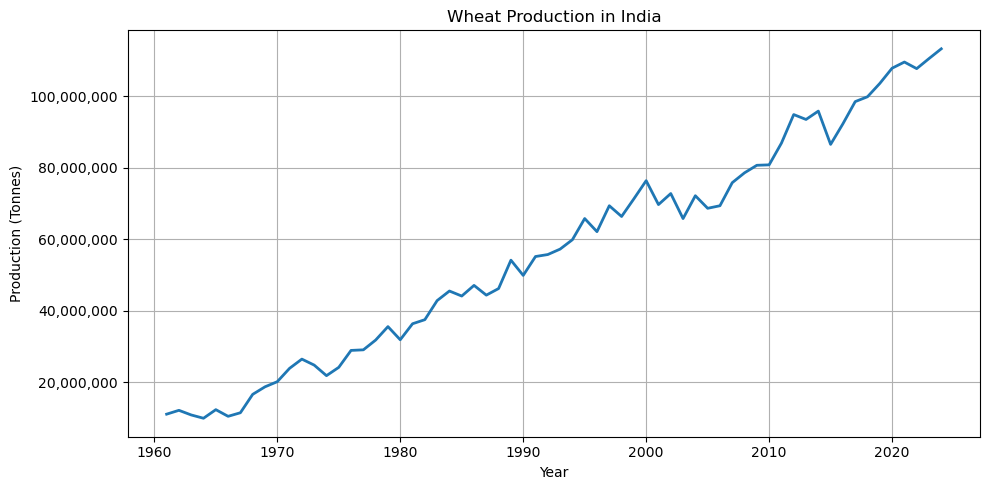

In [33]:
plt.figure(figsize=(10,5))
plt.plot(ts.index, ts["Production"], linewidth=2)

plt.title("Wheat Production in India")
plt.xlabel("Year")
plt.ylabel("Production (Tonnes)")

# Force plain numbers (no scientific notation)
plt.ticklabel_format(style='plain', axis='y')

# Add comma formatting (100,000,000 instead of 100000000)
plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
# Train-test split (80% train, 20% test)
# Split data into 80% training and 20% testing (chronological split)
train_size = int(len(ts) * 0.8)   # Calculate 80% of total observations
train = ts.iloc[:train_size]     # First 80% used to train models
test = ts.iloc[train_size:]      # Remaining 20% used to evaluate forecast accuracy

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 51
Test size: 13


In [35]:
# Naïve forecast (last value forecasting)
# Baseline model: Forecast future values using last observed training value
baseline_forecast = np.repeat(
    train["Production"].iloc[-1],   # Take last value from training data
    len(test)                       # Repeat it for length of test period
)

# Store results in DataFrame
baseline_df = pd.DataFrame({
    "Actual": test["Production"],          # True production values
    "Baseline Forecast": baseline_forecast # Naïve predictions
}, index=test.index)

In [36]:
# Fit SARIMA (you can adjust parameters later)
# Build SARIMA model
sarima_model = SARIMAX(
    train["Production"],        # Training data
    order=(1,1,1),              # (p,d,q) → AR, differencing, MA
    seasonal_order=(1,1,1,12),  # Seasonal components (P,D,Q,12 months)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fit the model
sarima_result = sarima_model.fit(disp=False)

# Forecast future values for test period
sarima_forecast = sarima_result.forecast(steps=len(test))

# Store results
sarima_df = pd.DataFrame({
    "Actual": test["Production"],
    "SARIMA Forecast": sarima_forecast
}, index=test.index)

C:\Users\soma mani deepak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\soma mani deepak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)


In [37]:
# Scale data
# Scale data between 0 and 1 (neural networks require normalization)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

# Function to create sequences (windowing)
def create_sequences(data, window=3):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])  # Past 3 years as input
        y.append(data[i+window])    # Next year as output
    return np.array(X), np.array(y)

window_size = 3
X_train, y_train = create_sequences(train_scaled, window_size)

# Build LSTM architecture
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(window_size,1)))  # 50 memory units
model.add(Dense(1))  # Output layer
model.compile(optimizer='adam', loss='mse')  # Minimize mean squared error

# Train the model
model.fit(X_train, y_train, epochs=100, verbose=0)

# Prepare test sequences
X_test, y_test = create_sequences(test_scaled, window_size)

# Forecast
lstm_forecast_scaled = model.predict(X_test)
lstm_forecast = scaler.inverse_transform(lstm_forecast_scaled)  # Convert back to tonnes

# Align forecast with correct dates
lstm_index = test.index[window_size:]

lstm_df = pd.DataFrame({
    "Actual": test["Production"].iloc[window_size:],
    "LSTM Forecast": lstm_forecast.flatten()
}, index=lstm_index)

C:\Users\soma mani deepak\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step


In [38]:
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)  # Average absolute error
    rmse = np.sqrt(mean_squared_error(actual, predicted))  # Penalizes large errors
    return mae, rmse
# Baseline
mae_base, rmse_base = evaluate(
    baseline_df["Actual"],
    baseline_df["Baseline Forecast"])

# SARIMA
mae_sarima, rmse_sarima = evaluate(
    sarima_df["Actual"],
    sarima_df["SARIMA Forecast"])

# LSTM
mae_lstm, rmse_lstm = evaluate(
    lstm_df["Actual"],
    lstm_df["LSTM Forecast"])

print("\nModel Comparison")
print("Baseline  → MAE:", mae_base, " RMSE:", rmse_base)
print("SARIMA    → MAE:", mae_sarima, " RMSE:", rmse_sarima)
print("LSTM      → MAE:", mae_lstm, " RMSE:", rmse_lstm)


Model Comparison
Baseline  → MAE: 14261314.870000001  RMSE: 16296520.219541792
SARIMA    → MAE: 8624402.24868536  RMSE: 9198411.66551939
LSTM      → MAE: 4496590.669  RMSE: 5879924.506985607


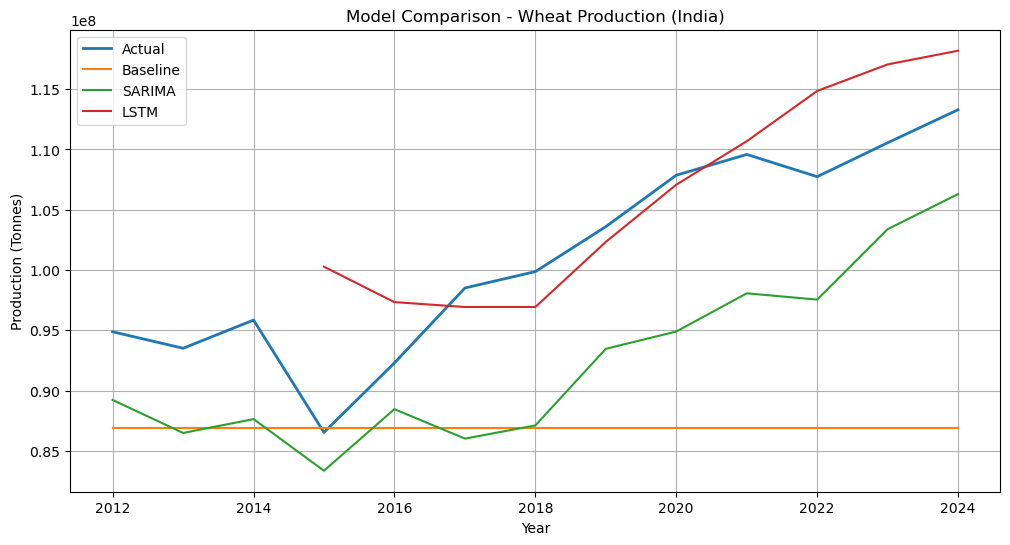

In [39]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test["Production"], label="Actual", linewidth=2)
plt.plot(test.index, baseline_forecast, label="Baseline")
plt.plot(sarima_forecast.index, sarima_forecast, label="SARIMA")
plt.plot(lstm_index, lstm_forecast, label="LSTM")

plt.title("Model Comparison - Wheat Production (India)")
plt.xlabel("Year")
plt.ylabel("Production (Tonnes)")
plt.legend()
plt.grid(True)
plt.show()